<a href="https://colab.research.google.com/github/Victoriaaahh/Calculo_Numerico/blob/main/Atividade_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade 1 -  Maria Luíza Margarido Balbo e Victoria Ayumi Kose**


---



**3) Parte A – truncamento e arredondamento**



                         RESULTADOS - X1
                         Valor de referência: 3.14159265
Método                n       Aproximação       Erro absoluto       Erro relativo      Erro percentual (%)
-------------------------------------------------------------------------------------------------------------------
Truncamento           0      3.0000000000    1.4159265000e-01    4.5070340357e-02         4.5070340357e+00
Arredondamento        0      3.0000000000    1.4159265000e-01    4.5070340357e-02         4.5070340357e+00
Truncamento           1      3.1000000000    4.1592650000e-02    1.3239351703e-02         1.3239351703e+00
Arredondamento        1      3.1000000000    4.1592650000e-02    1.3239351703e-02         1.3239351703e+00
Truncamento           2      3.1400000000    1.5926500000e-03    5.0695624081e-04         5.0695624081e-02
Arredondamento        2      3.1400000000    1.5926500000e-03    5.0695624081e-04         5.0695624081e-02
Truncamento           3      3.1410

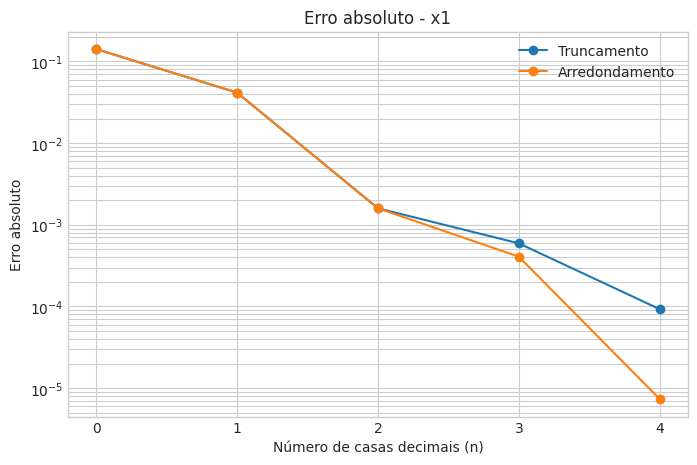

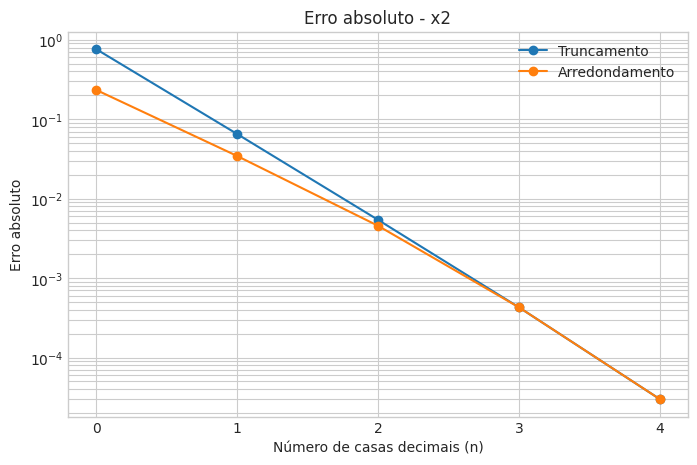

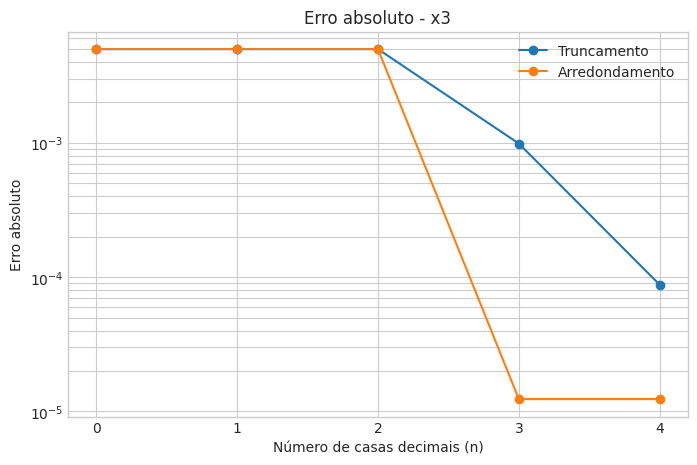

In [80]:
import math
import pandas as pd
import matplotlib.pyplot as plt


# Valores de referência
valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

# Casas decimais
casas = [0, 1, 2, 3, 4]


# Função para truncamento
def truncar(x, n):
    fator = 10 ** n
    return math.trunc(x * fator) / fator


# Lista para armazenar os resultados
resultados = []


# Calculando os erros
for nome, x in valores.items():

    for n in casas:

        # Truncamento
        xt = truncar(x, n)

        Ea_t = abs(x - xt)
        Er_t = Ea_t / abs(x)
        Epercent_t = 100 * Er_t

        resultados.append({
            "Valor": nome,
            "Método": "Truncamento",
            "n": n,
            "Aproximação": xt,
            "Erro absoluto": Ea_t,
            "Erro relativo": Er_t,
            "Erro percentual": Epercent_t
        })

        # Arredondamento
        xa = round(x, n)

        Ea_a = abs(x - xa)
        Er_a = Ea_a / abs(x)
        Epercent_a = 100 * Er_a

        resultados.append({
            "Valor": nome,
            "Método": "Arredondamento",
            "n": n,
            "Aproximação": xa,
            "Erro absoluto": Ea_a,
            "Erro relativo": Er_a,
            "Erro percentual": Epercent_a
        })


# CRIAR TABELA

df = pd.DataFrame(resultados)


# MOSTRAR TABELAS FORMATADAS

for nome, x in valores.items():

    tabela = df[df["Valor"] == nome]

    print("\n")
    print("=" * 115)
    print(f"                         RESULTADOS - {nome.upper()}")
    print(f"                         Valor de referência: {x}")
    print("=" * 115)

    print(
        f"{'Método':<18}"
        f"{'n':>5}"
        f"{'Aproximação':>18}"
        f"{'Erro absoluto':>20}"
        f"{'Erro relativo':>20}"
        f"{'Erro percentual (%)':>25}"
    )

    print("-" * 115)

    for _, linha in tabela.iterrows():

        print(
            f"{linha['Método']:<18}"
            f"{linha['n']:>5}"
            f"{linha['Aproximação']:>18.10f}"
            f"{linha['Erro absoluto']:>20.10e}"
            f"{linha['Erro relativo']:>20.10e}"
            f"{linha['Erro percentual']:>25.10e}"
        )

    print("=" * 115)

# GRÁFICOS

for nome in valores:

    plt.figure(figsize=(8, 5))

    dados_trunc = df[
        (df["Valor"] == nome) &
        (df["Método"] == "Truncamento")
    ]

    dados_arred = df[
        (df["Valor"] == nome) &
        (df["Método"] == "Arredondamento")
    ]

    plt.plot(
        dados_trunc["n"],
        dados_trunc["Erro absoluto"],
        marker="o",
        label="Truncamento"
    )

    plt.plot(
        dados_arred["n"],
        dados_arred["Erro absoluto"],
        marker="o",
        label="Arredondamento"
    )

    plt.yscale("log")

    plt.xlabel("Número de casas decimais (n)")
    plt.ylabel("Erro absoluto")
    plt.title(f"Erro absoluto - {nome}")

    plt.xticks(casas)
    plt.grid(True, which="both")
    plt.legend()

    plt.show()

**3.5) responda: arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.**

Não. Arredondar não gera necessariamente um erro menor ou igual ao truncamento em todos os casos.

O arredondamento geralmente apresenta erro menor ou igual ao truncamento porque considera o primeiro algarismo que será descartado, podendo aproximar o valor para o lado mais próximo do valor real. Entretanto, dependendo do valor e da quantidade de casas decimais, arredondamento e truncamento podem produzir o mesmo resultado e, consequentemente, o mesmo erro.

Por exemplo, para \(x1= 3,14159265\) com 3 casas decimais:


*   truncamento: \(3,141\), com \(Ea= 0,00059265\);
*   arredondamento: \(3,142\), com \(Ea= 0,00040735\).


Assim, nesse caso, o arredondamento apresenta erro menor. Portanto, os resultados mostram que o arredondamento pode ser melhor que o truncamento, mas não é correto afirmar simplesmente que eles sempre produzirão erros diferentes. Em algumas situações, ambos produzem exatamente a mesma aproximação e o mesmo erro.

**4) Parte B – medidas de pressão arterial**

Média de Referência (exata): 121.120000 mmHg

Série                        | Média    | Mín    | Máx    | Ampl   | Desv.Padr | Ea (mmHg)  | Er (%)  
---------------------------------------------------------------------------------------------------------
1. Originais                 | 121.12   | 119.8  | 122.4  | 2.6    | 0.8337    | 0.000000   | 0.0000  %
2. Arredondados (Inteiro)    | 121.10   | 120.0  | 122.0  | 2.0    | 0.8756    | 0.020000   | 0.0165  %
3. Truncados (Inteiro)       | 120.70   | 119.0  | 122.0  | 3.0    | 0.9487    | 0.420000   | 0.3468  %
4. Arredondados (1 casa)     | 121.12   | 119.8  | 122.4  | 2.6    | 0.8337    | 0.000000   | 0.0000  %


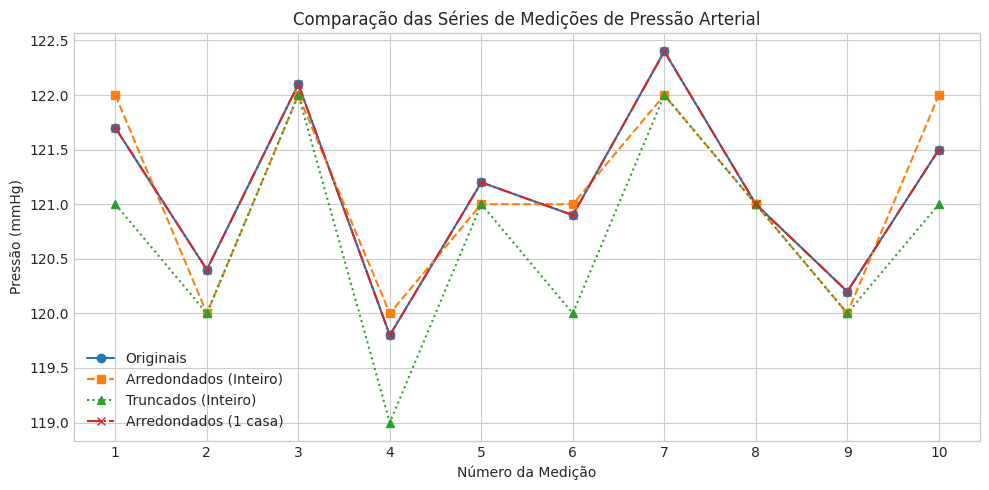

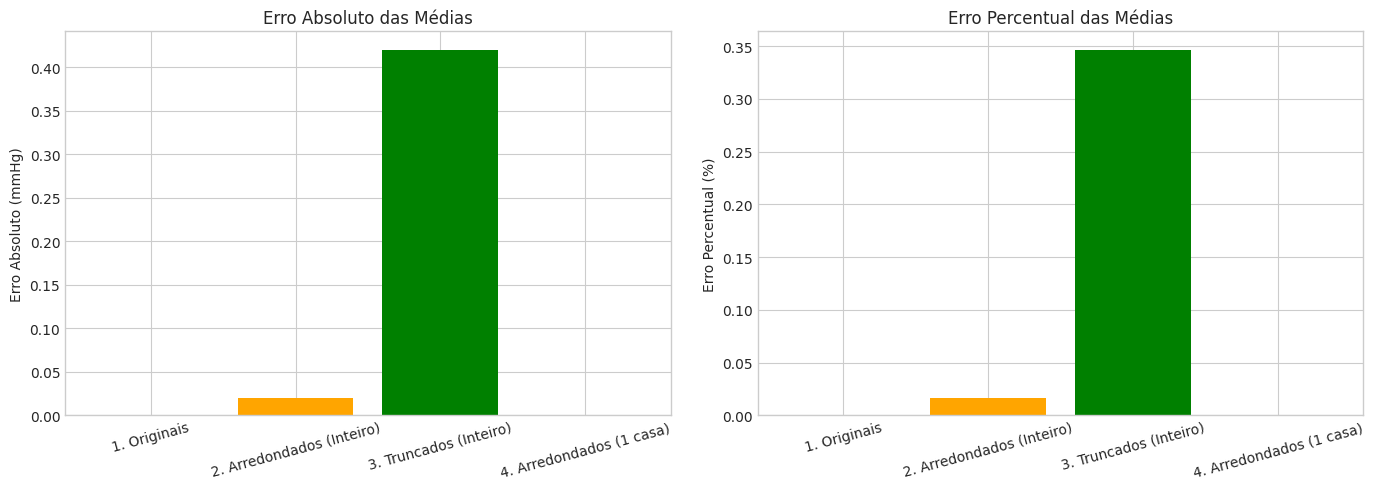

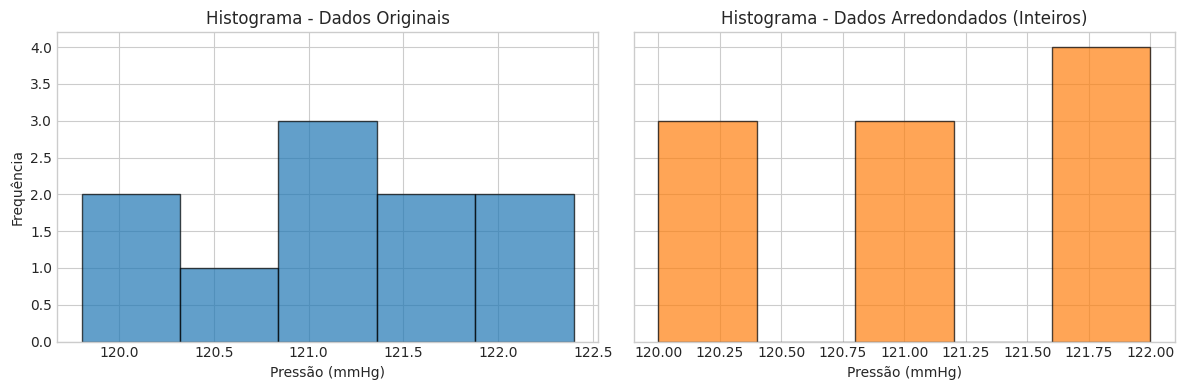

In [72]:

# 1. DEFINIÇÃO DOS DADOS E SÉRIES
# Dados originais de pressão arterial sistólica (em mmHg)
dados_originais = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

# 1. Dados originais
srie_1 = dados_originais

# 2. Dados arredondados para o inteiro mais próximo
srie_2 = np.round(dados_originais)


# 3. Dados truncados para números inteiros (sem arredondar)
def truncar(x, casas=0):
    fator = 10**casas
    return np.trunc(x * fator) / fator


srie_3 = truncar(dados_originais, 0)

# 4. Dados arredondados para uma casa decimal (já estão com 1, mas aplicamos a função)
srie_4 = np.round(dados_originais, 1)

# Dicionário para facilitar a manipulação iterativa
series = {
    "1. Originais": srie_1,
    "2. Arredondados (Inteiro)": srie_2,
    "3. Truncados (Inteiro)": srie_3,
    "4. Arredondados (1 casa)": srie_4,
}

# 2. ESTATÍSTICAS DESCRITIVAS E ERROS
# Referência: Média calculada com todos os algarismos disponíveis (dados originais)
media_ref = np.mean(dados_originais)

print(f"Média de Referência (exata): {media_ref:.6f} mmHg\n")
print(
    f"{'Série':<28} | {'Média':<8} | {'Mín':<6} | {'Máx':<6} | {'Ampl':<6} | {'Desv.Padr':<9} | {'Ea (mmHg)':<10} | {'Er (%)':<8}"
)
print("-" * 105)

resultados = {}

for nome, serie in series.items():
    media_aprox = np.mean(serie)
    minimo = np.min(serie)
    maximo = np.max(serie)
    amplitude = maximo - minimo
    # Desvio-padrão amostral (ddof=1)
    desvio_padrao = np.std(serie, ddof=1)

    # Cálculo dos erros da média aproximada em relação à referência
    ea = abs(media_ref - media_aprox)
    er = ea / abs(media_ref)
    epc = 100.0 * er

    resultados[nome] = {
        "media": media_aprox,
        "min": minimo,
        "max": maximo,
        "amplitude": amplitude,
        "desvio": desvio_padrao,
        "ea": ea,
        "er": er,
        "epc": epc,
    }

    print(
        f"{nome:<28} | {media_aprox:<8.2f} | {minimo:<6.1f} | {maximo:<6.1f} | {amplitude:<6.1f} | {desvio_padrao:<9.4f} | {ea:<10.6f} | {epc:<8.4f}%"
    )

# 3. GRÁFICOS OBRIGATÓRIOS

# Gráfico 1: As dez medições mostrando as quatro séries
plt.figure(figsize=(10, 5))
x_eixo = np.arange(1, 11)
plt.plot(
    x_eixo,
    srie_1,
    marker="o",
    linestyle="-",
    label="Originais",
    color="tab:blue",
)
plt.plot(
    x_eixo,
    srie_2,
    marker="s",
    linestyle="--",
    label="Arredondados (Inteiro)",
    color="tab:orange",
)
plt.plot(
    x_eixo,
    srie_3,
    marker="^",
    linestyle=":",
    label="Truncados (Inteiro)",
    color="tab:green",
)
plt.plot(
    x_eixo,
    srie_4,
    marker="x",
    linestyle="-.",
    label="Arredondados (1 casa)",
    color="tab:red",
)
plt.title("Comparação das Séries de Medições de Pressão Arterial")
plt.xlabel("Número da Medição")
plt.ylabel("Pressão (mmHg)")
plt.xticks(x_eixo)
plt.legend()
plt.tight_layout()
plt.show()

# Gráficos 2 e 3: Erros Absolutos e Percentuais das Médias
nomes_series = list(resultados.keys())
erros_abs = [resultados[k]["ea"] for k in nomes_series]
erros_perc = [resultados[k]["epc"] for k in nomes_series]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(nomes_series, erros_abs, color=["blue", "orange", "green", "red"])
ax1.set_title("Erro Absoluto das Médias")
ax1.set_ylabel("Erro Absoluto (mmHg)")
ax1.tick_params(axis="x", rotation=15)

ax2.bar(nomes_series, erros_perc, color=["blue", "orange", "green", "red"])
ax2.set_title("Erro Percentual das Médias")
ax2.set_ylabel("Erro Percentual (%)")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Gráfico 4: Histogramas (Dados originais vs. Dados inteiros arredondados)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.hist(
    dados_originais,
    bins=5,
    color="tab:blue",
    edgecolor="black",
    alpha=0.7,
)
ax1.set_title("Histograma - Dados Originais")
ax1.set_xlabel("Pressão (mmHg)")
ax1.set_ylabel("Frequência")

ax2.hist(
    srie_2, bins=5, color="tab:orange", edgecolor="black", alpha=0.7
)
ax2.set_title("Histograma - Dados Arredondados (Inteiros)")
ax2.set_xlabel("Pressão (mmHg)")

plt.tight_layout()
plt.show()

**4) Explique se a representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra. Não faça interpretação médica dos valores.**

A representação inteira não é totalmente suficiente para preservar a variabilidade fina da amostra. Embora o arredondamento mantenha a média razoavelmente estável, a perda de precisão decimal degrada a capacidade de descrever flutuações sutis em conjuntos pequenos de dados médicos.

**5) Parte C – vazão em um tubo de pequeno diâmetro**

VALOR DE REFERÊNCIA
Q referência = 2.7574207520e-07 m³/s
Q referência = 0.275742 mL/s

                                                    C.1 - RESULTADOS                                                    
Cenário                      r (mm)    μ (Pa.s)     Δp (Pa)          Q (m³/s)     Erro absoluto   Erro relativo    Erro (%)
------------------------------------------------------------------------------------------------------------------------
Valores originais              0.80      0.0035        1200      2.757421e-07      0.000000e+00    0.000000e+00    0.000000
r arredondado                  0.80      0.0035        1200      2.757421e-07      0.000000e+00    0.000000e+00    0.000000
r truncado                     0.80      0.0035        1200      2.757421e-07      0.000000e+00    0.000000e+00    0.000000
mu arredondada                 0.80      0.0040        1200      2.412743e-07      3.446776e-08    1.250000e-01   12.500000
mu truncada                    0.80      0.0030    

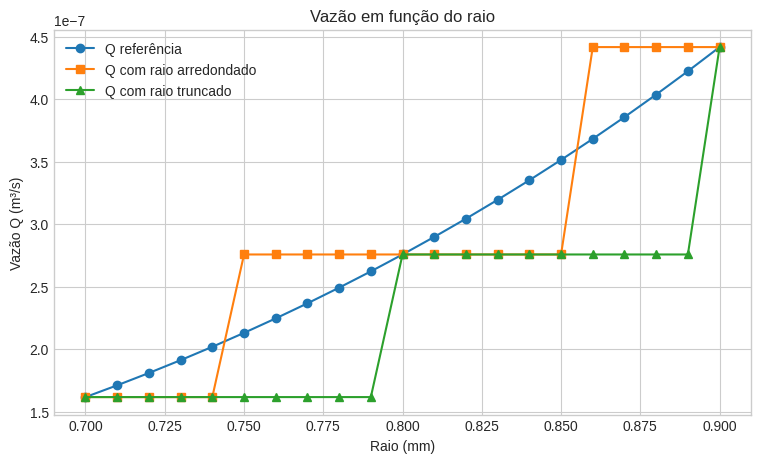

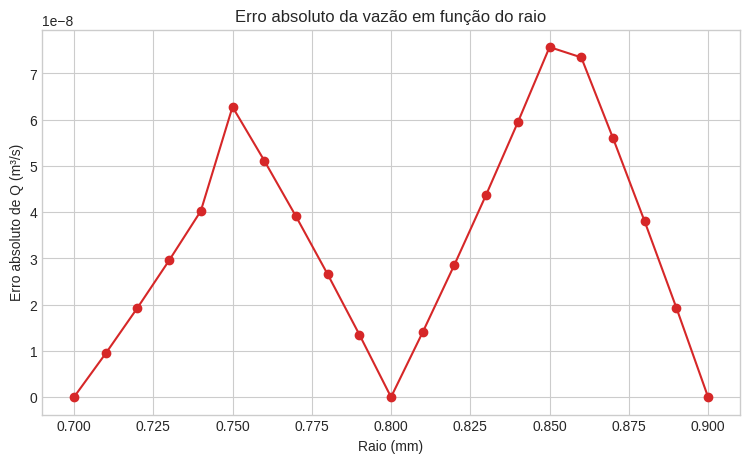

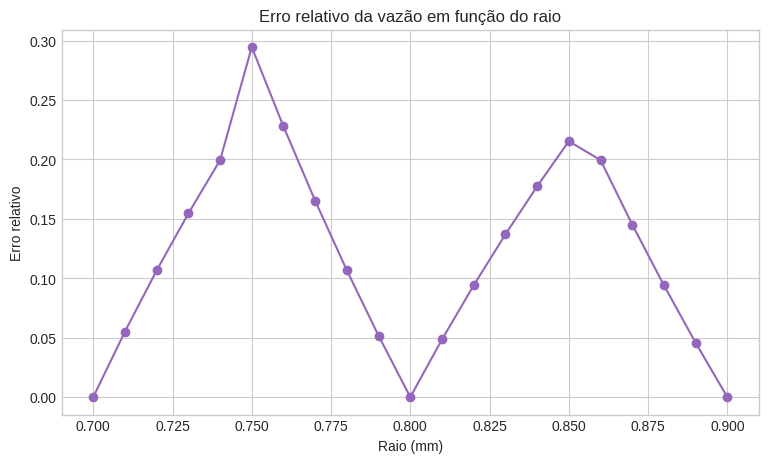

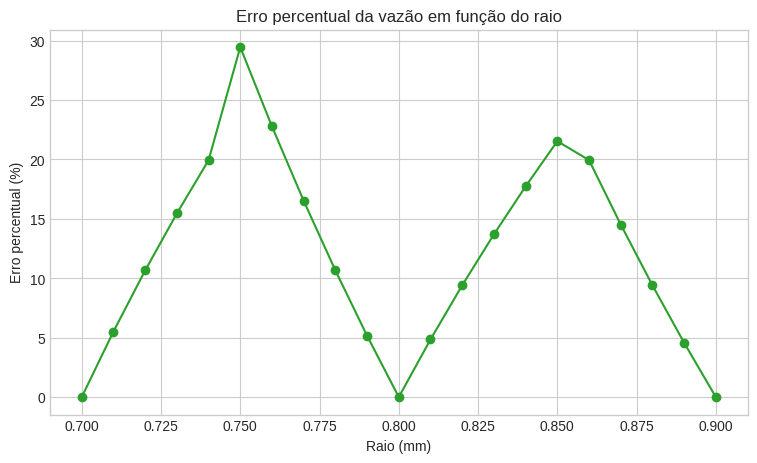

In [73]:


# Configuração visual padrão
plt.style.use("seaborn-v0_8-whitegrid")

# DADOS
r = 0.80  # mm
L = 0.20  # m
mu = 3.5e-3  # Pa.s
dp = 1200  # Pa

# Conversão do raio para metros
r_m = r / 1000


# FUNÇÃO DE HAGEN-POISEUILLE
def vazao(r, mu, dp, L):
    """r -> raio em metros

    mu -> viscosidade em Pa.s dp -> diferença de pressão em Pa L -> comprimento
    em metros
    """
    return (np.pi * r**4 * dp) / (8 * mu * L)


# VALOR DE REFERÊNCIA
Q_ref = vazao(r_m, mu, dp, L)

print("=" * 60)
print("VALOR DE REFERÊNCIA")
print("=" * 60)
print(f"Q referência = {Q_ref:.10e} m³/s")
print(f"Q referência = {Q_ref * 1e6:.6f} mL/s\n")


# FUNÇÃO PARA CALCULAR ERROS
def calcular_erros(Q):
    Ea = abs(Q_ref - Q)
    Er = Ea / abs(Q_ref)
    Epercentual = 100 * Er
    return Ea, Er, Epercentual


# C.1 - PRECISÃO DAS VARIÁVEIS
cenarios = []

# 1. Todos os valores fornecidos
Q = vazao(r_m, mu, dp, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "Valores originais",
        "r (mm)": r,
        "mu (Pa.s)": mu,
        "dp (Pa)": dp,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 2. Raio arredondado para 1 casa decimal
r_arred = round(r, 1)
Q = vazao(r_arred / 1000, mu, dp, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "r arredondado",
        "r (mm)": r_arred,
        "mu (Pa.s)": mu,
        "dp (Pa)": dp,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 3. Raio truncado para 1 casa decimal
r_trunc = math.trunc(r * 10) / 10
Q = vazao(r_trunc / 1000, mu, dp, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "r truncado",
        "r (mm)": r_trunc,
        "mu (Pa.s)": mu,
        "dp (Pa)": dp,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 4. μ arredondada para 3 casas decimais
mu_arred = round(mu, 3)
Q = vazao(r_m, mu_arred, dp, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "mu arredondada",
        "r (mm)": r,
        "mu (Pa.s)": mu_arred,
        "dp (Pa)": dp,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 5. μ truncada para 3 casas decimais
mu_trunc = math.trunc(mu * 1000) / 1000
Q = vazao(r_m, mu_trunc, dp, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "mu truncada",
        "r (mm)": r,
        "mu (Pa.s)": mu_trunc,
        "dp (Pa)": dp,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 6. Δp arredondado para centenas
dp_arred = round(dp / 100) * 100
Q = vazao(r_m, mu, dp_arred, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "dp arredondado",
        "r (mm)": r,
        "mu (Pa.s)": mu,
        "dp (Pa)": dp_arred,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 7. Δp truncado para centenas
dp_trunc = math.trunc(dp / 100) * 100
Q = vazao(r_m, mu, dp_trunc, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "dp truncado",
        "r (mm)": r,
        "mu (Pa.s)": mu,
        "dp (Pa)": dp_trunc,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# 8. Todas as aproximações simultaneamente
Q = vazao(r_arred / 1000, mu_arred, dp_arred, L)
Ea, Er, Ep = calcular_erros(Q)
cenarios.append(
    {
        "Cenário": "Todas as aproximações",
        "r (mm)": r_arred,
        "mu (Pa.s)": mu_arred,
        "dp (Pa)": dp_arred,
        "Q (m³/s)": Q,
        "Erro absoluto": Ea,
        "Erro relativo": Er,
        "Erro percentual (%)": Ep,
    }
)

# Conversão da lista em DataFrame do Pandas (Correção principal)
df = pd.DataFrame(cenarios)

# TABELA
print("=" * 120)
print(f"{'C.1 - RESULTADOS':^120}")
print("=" * 120)

print(
    f"{'Cenário':<25}"
    f"{'r (mm)':>10}"
    f"{'μ (Pa.s)':>12}"
    f"{'Δp (Pa)':>12}"
    f"{'Q (m³/s)':>18}"
    f"{'Erro absoluto':>18}"
    f"{'Erro relativo':>16}"
    f"{'Erro (%)':>12}"
)
print("-" * 120)

for _, linha in df.iterrows():
    print(
        f"{linha['Cenário']:<25}"
        f"{linha['r (mm)']:>10.2f}"
        f"{linha['mu (Pa.s)']:>12.4f}"
        f"{linha['dp (Pa)']:>12.0f}"
        f"{linha['Q (m³/s)']:>18.6e}"
        f"{linha['Erro absoluto']:>18.6e}"
        f"{linha['Erro relativo']:>16.6e}"
        f"{linha['Erro percentual (%)']:>12.6f}"
    )
print("=" * 120 + "\n")


# C.2 - SENSIBILIDADE AO RAIO
raios = np.arange(0.70, 0.901, 0.01)

Q_referencia = []
Q_arredondado = []
Q_truncado = []
erro_absoluto = []
erro_relativo = []
erro_percentual = []

for raio in raios:
    Q_ref_raio = vazao(raio / 1000, mu, dp, L)

    raio_arred = round(raio, 1)
    Q_arred = vazao(raio_arred / 1000, mu, dp, L)

    raio_trunc = math.trunc(raio * 10) / 10
    Q_trunc = vazao(raio_trunc / 1000, mu, dp, L)

    Q_referencia.append(Q_ref_raio)
    Q_arredondado.append(Q_arred)
    Q_truncado.append(Q_trunc)

    Ea = abs(Q_ref_raio - Q_arred)
    Er = Ea / abs(Q_ref_raio)
    Ep = Er * 100

    erro_absoluto.append(Ea)
    erro_relativo.append(Er)
    erro_percentual.append(Ep)

# GRÁFICOS
plt.figure(figsize=(9, 5))
plt.plot(raios, Q_referencia, marker="o", label="Q referência")
plt.plot(raios, Q_arredondado, marker="s", label="Q com raio arredondado")
plt.plot(raios, Q_truncado, marker="^", label="Q com raio truncado")
plt.xlabel("Raio (mm)")
plt.ylabel("Vazão Q (m³/s)")
plt.title("Vazão em função do raio")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(raios, erro_absoluto, marker="o", color="tab:red")
plt.xlabel("Raio (mm)")
plt.ylabel("Erro absoluto de Q (m³/s)")
plt.title("Erro absoluto da vazão em função do raio")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(raios, erro_relativo, marker="o", color="tab:purple")
plt.xlabel("Raio (mm)")
plt.ylabel("Erro relativo")
plt.title("Erro relativo da vazão em função do raio")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(raios, erro_percentual, marker="o", color="tab:green")
plt.xlabel("Raio (mm)")
plt.ylabel("Erro percentual (%)")
plt.title("Erro percentual da vazão em função do raio")
plt.grid(True)
plt.show()

**5) C.2 Sensibilidade**

O erro no raio é amplificado na vazão porque, na equação de Hagen–Poiseuille, o raio aparece elevado à quarta potência. Assim, pequenas variações no raio provocam variações muito maiores na vazão. Por exemplo, se o raio sofrer uma variação de 10%, a vazão não sofrerá apenas uma variação de 10%, pois depende de \(r^4\). Para um aumento de 10% no raio, a vazão é multiplicada por \(1,1^4=1,4641\), correspondendo a aproximadamente 46,4% de aumento. Isso mostra que a vazão é altamente sensível a pequenas alterações geométricas do tubo. Em um nanocateter, essa sensibilidade é ainda mais relevante, pois pequenas diferenças nas dimensões do canal podem produzir alterações significativas no escoamento.

Uma observação sobre o gráfico

No intervalo pedido:

$$ 0,70\leq r\leq0,90\text{ mm} $$

você deve perceber que a curva de \(Q\) cresce bem rapidamente conforme o raio aumenta.

Isso ocorre porque:

$$ Q\propto r^4 $$

Por exemplo, comparando \(0,70\) mm com \(0,90\) mm:

$$ \frac{Q_{0,90}}{Q_{0,70}} = \left(\frac{0,90}{0,70}\right)^4 \approx2,73 $$

Ou seja, aumentar o raio de 0,70 para 0,90 mm — uma mudança de apenas 28,6% — produz uma vazão aproximadamente 2,73 vezes maior. Isso é exatamente o fenômeno que a atividade quer que você observe.

**6) Parte D – escoamento em um nanocateter**

VAZÃO DE REFERÊNCIA
Raio: 50.0 nm
Comprimento: 10.0 um
Viscosidade: 3.50e-03 Pa.s
Queda de pressão: 5000 Pa
Vazão de referência Q(r): 3.506242e-19 m³/s



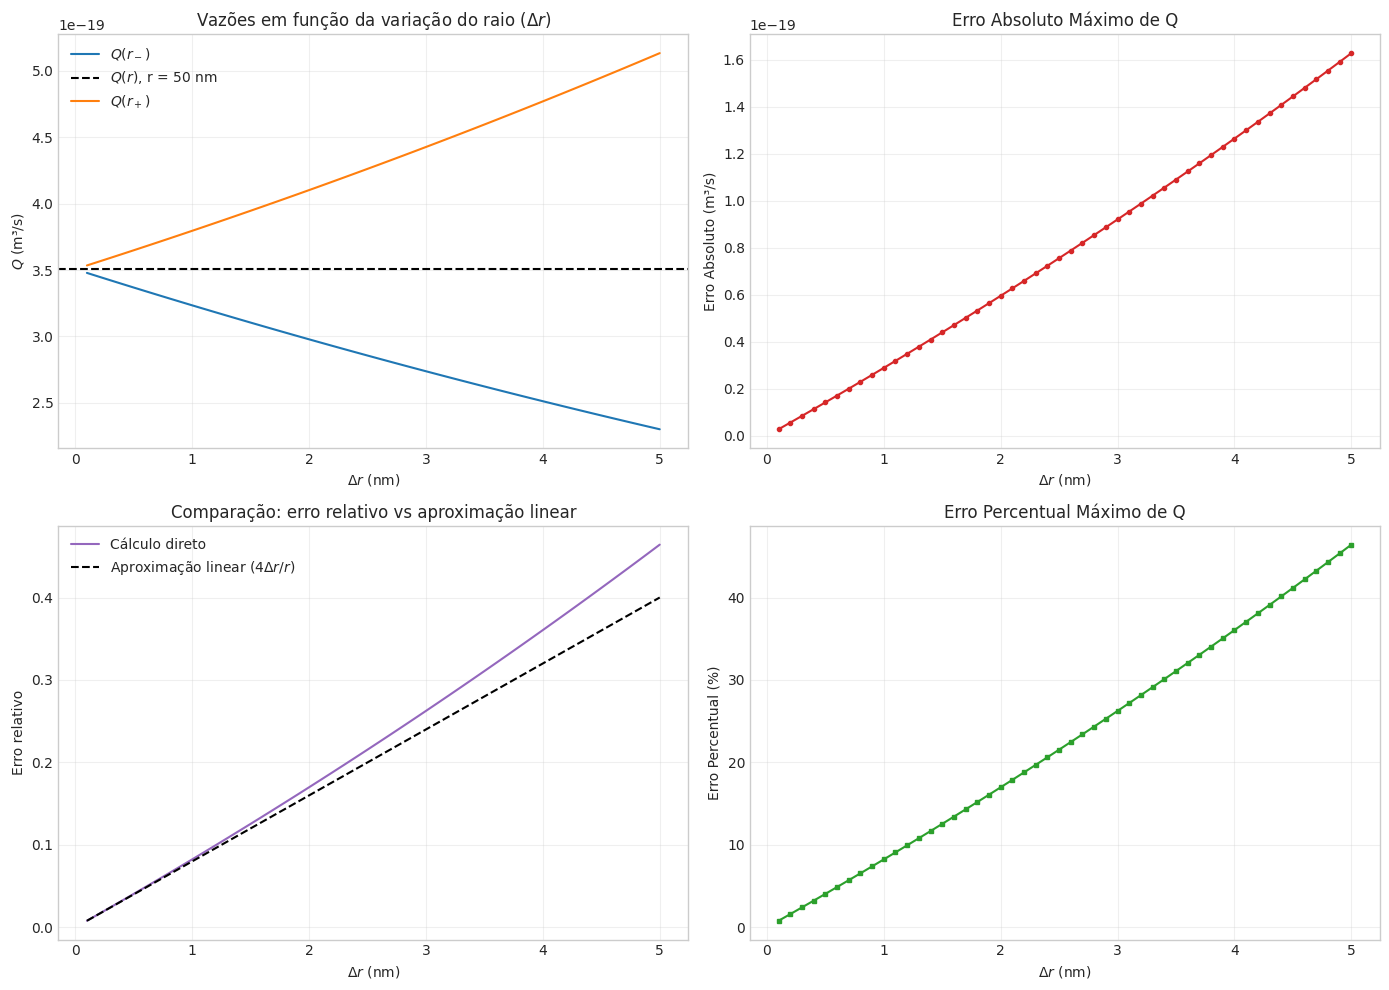

COMPARAÇÃO DE PRECISÃO COMPUTACIONAL
Epsilon float32: 1.192093e-07
Epsilon float64: 2.220446e-16

r^4 (float32): 6.250000395977423e-30
r^4 (float64): 6.249999999999999e-30

Q (float32): 3.506242323744234e-19 m³/s
Q (float64): 3.506241800881465e-19 m³/s

Diferença absoluta: 5.228628e-26 m³/s
Diferença relativa: 1.491234e-07
Diferença percentual: 1.491234e-05%



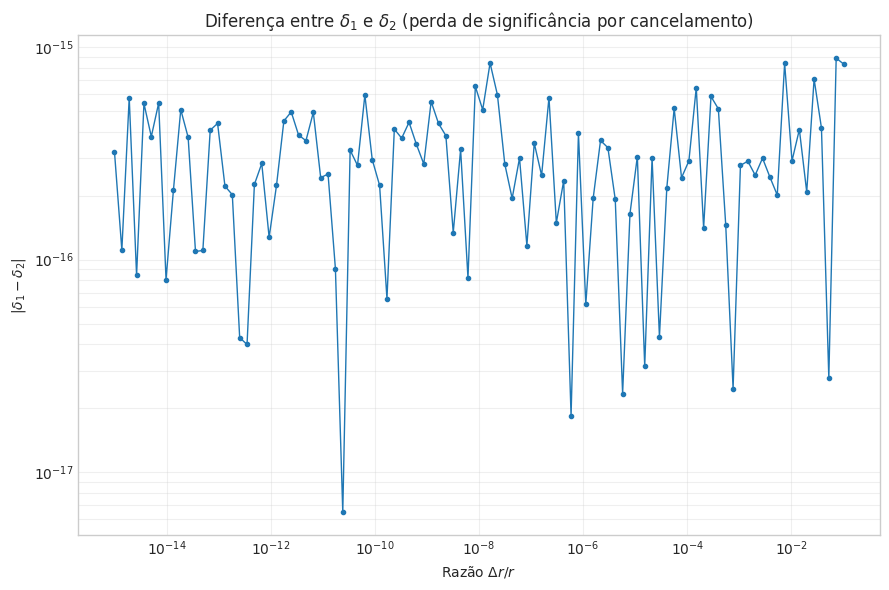

In [78]:
import numpy as np
import matplotlib.pyplot as plt


# PARÂMETROS DO MODELO - NANOCATETER

r = 50.0e-9          # Raio em metros (50 nm)
L = 10.0e-6         # Comprimento em metros (10 um)
mu = 3.5e-3         # Viscosidade dinâmica (Pa.s)
delta_p = 5000.0    # Queda de pressão (Pa)


# FUNÇÃO DE HAGEN-POISEUILLE

def calcular_q(raio):
    return (
        np.pi * (raio ** 4) * delta_p
        /
        (8 * mu * L)
    )


# VAZÃO DE REFERÊNCIA

q_ref = calcular_q(r)

print("=" * 60)
print("VAZÃO DE REFERÊNCIA")
print("=" * 60)

print(f"Raio: {r * 1e9:.1f} nm")
print(f"Comprimento: {L * 1e6:.1f} um")
print(f"Viscosidade: {mu:.2e} Pa.s")
print(f"Queda de pressão: {delta_p:.0f} Pa")
print(f"Vazão de referência Q(r): {q_ref:.6e} m³/s")
print()


# D.1 - ERRO GEOMÉTRICO E SENSIBILIDADE


# Variações de raio:
# delta_r = 0.1 até 5.0 nm

delta_r_vals = np.arange(
    0.1e-9,
    5.1e-9,
    0.1e-9
)


# Raios menor e maior que o valor de referência

r_minus = r - delta_r_vals
r_plus = r + delta_r_vals


# Vazões correspondentes

q_minus = calcular_q(r_minus)
q_plus = calcular_q(r_plus)


# ERROS MÁXIMOS

erro_abs_max = np.maximum(
    np.abs(q_ref - q_minus),
    np.abs(q_ref - q_plus)
)

erro_rel_max = erro_abs_max / q_ref

erro_perc_max = 100.0 * erro_rel_max


# GRÁFICOS D.1


fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


# 1. Q(r-), Q(r) e Q(r+)

axs[0, 0].plot(
    delta_r_vals * 1e9,
    q_minus,
    label=r"$Q(r_-)$",
    color="tab:blue"
)

axs[0, 0].axhline(
    q_ref,
    color="black",
    linestyle="--",
    label=r"$Q(r)$, r = 50 nm"
)

axs[0, 0].plot(
    delta_r_vals * 1e9,
    q_plus,
    label=r"$Q(r_+)$",
    color="tab:orange"
)

axs[0, 0].set_title(
    r"Vazões em função da variação do raio ($\Delta r$)"
)

axs[0, 0].set_xlabel(
    r"$\Delta r$ (nm)"
)

axs[0, 0].set_ylabel(
    r"$Q$ (m³/s)"
)

axs[0, 0].legend()

axs[0, 0].grid(
    True,
    alpha=0.3
)


# 2. ERRO ABSOLUTO MÁXIMO

axs[0, 1].plot(
    delta_r_vals * 1e9,
    erro_abs_max,
    color="tab:red",
    marker="o",
    markersize=3
)

axs[0, 1].set_title(
    "Erro Absoluto Máximo de Q"
)

axs[0, 1].set_xlabel(
    r"$\Delta r$ (nm)"
)

axs[0, 1].set_ylabel(
    "Erro Absoluto (m³/s)"
)

axs[0, 1].grid(
    True,
    alpha=0.3
)



# 3. ERRO RELATIVO X APROXIMAÇÃO LINEAR

# Aproximação:

# dQ / Q aproximadamente igual a 4 * dr / r

erro_rel_linear = 4.0 * (
    delta_r_vals / r
)


axs[1, 0].plot(
    delta_r_vals * 1e9,
    erro_rel_max,
    label="Cálculo direto",
    color="tab:purple"
)

axs[1, 0].plot(
    delta_r_vals * 1e9,
    erro_rel_linear,
    label=r"Aproximação linear ($4\Delta r/r$)",
    linestyle="--",
    color="black"
)

axs[1, 0].set_title(
    "Comparação: erro relativo vs aproximação linear"
)

axs[1, 0].set_xlabel(
    r"$\Delta r$ (nm)"
)

axs[1, 0].set_ylabel(
    "Erro relativo"
)

axs[1, 0].legend()

axs[1, 0].grid(
    True,
    alpha=0.3
)


# ----------------------------------------------------------
# 4. ERRO PERCENTUAL MÁXIMO
# ----------------------------------------------------------

axs[1, 1].plot(
    delta_r_vals * 1e9,
    erro_perc_max,
    color="tab:green",
    marker="s",
    markersize=3
)

axs[1, 1].set_title(
    "Erro Percentual Máximo de Q"
)

axs[1, 1].set_xlabel(
    r"$\Delta r$ (nm)"
)

axs[1, 1].set_ylabel(
    "Erro Percentual (%)"
)

axs[1, 1].grid(
    True,
    alpha=0.3
)


plt.tight_layout()
plt.show()


# D.2 - PRECISÃO COMPUTACIONAL
# FLOAT32 VS FLOAT64

r_f32 = np.float32(r)
r_f64 = np.float64(r)


# Potência r^4

r4_f32 = r_f32 ** 4
r4_f64 = r_f64 ** 4


# Vazão float32

q_f32 = (
    np.float32(np.pi)
    * r4_f32
    * np.float32(delta_p)
) / (
    np.float32(8.0)
    * np.float32(mu)
    * np.float32(L)
)


# Vazão float64

q_f64 = (
    np.float64(np.pi)
    * r4_f64
    * np.float64(delta_p)
) / (
    np.float64(8.0)
    * np.float64(mu)
    * np.float64(L)
)


# Diferenças

diff_abs_q = np.abs(
    np.float64(q_f32) - q_f64
)

diff_rel_q = (
    diff_abs_q / np.abs(q_f64)
)


# RESULTADOS FLOAT32 X FLOAT64

print("=" * 60)
print("COMPARAÇÃO DE PRECISÃO COMPUTACIONAL")
print("=" * 60)

print(
    f"Epsilon float32: "
    f"{np.finfo(np.float32).eps:.6e}"
)

print(
    f"Epsilon float64: "
    f"{np.finfo(np.float64).eps:.6e}"
)

print()

print(
    f"r^4 (float32): "
    f"{r4_f32:.15e}"
)

print(
    f"r^4 (float64): "
    f"{r4_f64:.15e}"
)

print()

print(
    f"Q (float32): "
    f"{q_f32:.15e} m³/s"
)

print(
    f"Q (float64): "
    f"{q_f64:.15e} m³/s"
)

print()

print(
    f"Diferença absoluta: "
    f"{diff_abs_q:.6e} m³/s"
)

print(
    f"Diferença relativa: "
    f"{diff_rel_q:.6e}"
)

print(
    f"Diferença percentual: "
    f"{diff_rel_q * 100:.6e}%"
)

print()


# ANÁLISE DE CANCELAMENTO NUMÉRICO

fracoes_dr = np.logspace(
    -15,
    -1,
    100
)

delta_r_arr = (
    fracoes_dr * r
)


# Método 1

delta_1 = (
    calcular_q(r + delta_r_arr)
    - calcular_q(r)
) / calcular_q(r)


# Método 2

delta_2 = (
    1.0 + delta_r_arr / r
) ** 4 - 1.0


# Diferença entre os métodos

diferenca = np.abs(
    delta_1 - delta_2
)



# GRÁFICO DE CANCELAMENTO

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fracoes_dr,
    diferenca,
    color="tab:blue",
    marker=".",
    linewidth=1
)

plt.yscale("log")
plt.xscale("log")

plt.title(
    r"Diferença entre $\delta_1$ e $\delta_2$ "
    r"(perda de significância por cancelamento)"
)

plt.xlabel(
    r"Razão $\Delta r / r$"
)

plt.ylabel(
    r"$|\delta_1-\delta_2|$"
)

plt.grid(
    True,
    which="both",
    alpha=0.3
)

plt.tight_layout()
plt.show()

**7) Parte E – síntese visual**

In [75]:

# CONFIGURACAO

plt.rcParams["font.family"] = "DejaVu Sans"


# DADOS

L = 0.20
mu = 3.5e-3
dp = 1200.0

r_mm = 0.80
r_m = r_mm / 1000


# FUNCAO DE HAGEN-POISEUILLE

def vazao(r, mu, dp, L):
    return (np.pi * r**4 * dp) / (8 * mu * L)


# Vazao de referencia
Q_ref = vazao(
    r_m,
    mu,
    dp,
    L
)


# TRUNCAMENTO X ARREDONDAMENTO

x = 3.14159265
n = 3

x_trunc = np.trunc(x * 10**n) / 10**n
x_arred = round(x, n)


# Erro do truncamento
Ea_trunc = abs(x - x_trunc)
Er_trunc = Ea_trunc / abs(x)
Ep_trunc = 100 * Er_trunc


# Erro do arredondamento
Ea_arred = abs(x - x_arred)
Er_arred = Ea_arred / abs(x)
Ep_arred = 100 * Er_arred

# TRES TIPOS DE ERRO

erro_absoluto = Ea_trunc
erro_relativo = Er_trunc
erro_percentual = Ep_trunc

# SENSIBILIDADE AO RAIO

raios_nm = np.linspace(
    45,
    55,
    101
)

raios_m = raios_nm * 1e-9

Q_raios = vazao(
    raios_m,
    mu,
    dp,
    L
)

# FLOAT32 X FLOAT64

def vazao_float(
    r,
    mu,
    dp,
    L,
    dtype
):

    r = dtype(r)
    mu = dtype(mu)
    dp = dtype(dp)
    L = dtype(L)

    return (
        dtype(np.pi)
        * r**dtype(4)
        * dp
        /
        (
            dtype(8)
            * mu
            * L
        )
    )


Q64 = vazao_float(
    50e-9,
    mu,
    dp,
    L,
    np.float64
)

Q32 = vazao_float(
    50e-9,
    mu,
    dp,
    L,
    np.float32
)


erro_float_absoluto = abs(
    Q64 - Q32
)

erro_float_percentual = (
    100
    * erro_float_absoluto
    / abs(Q64)
)

# CRIAR FIGURA

fig = plt.figure(
    figsize=(18, 11),
    dpi=100
)

fig.patch.set_facecolor("white")

# TITULO

fig.suptitle(
    "Calculo Numerico - Sintese Visual do Nanocateter",
    fontsize=25,
    fontweight="bold",
    y=0.97
)

# CARTOES

cartoes = [
    (
        "Pressao dp",
        f"{dp:.0f} Pa"
    ),

    (
        "Raio de referencia",
        f"{r_mm:.2f} mm"
    ),

    (
        "Vazao Q",
        f"{Q_ref:.4e} m3/s"
    ),

    (
        "Vazao Q",
        f"{Q_ref * 1e9:.4f} nL/s"
    )
]


posicoes = [
    0.04,
    0.28,
    0.52,
    0.76
]


for (
    (titulo, valor),
    xpos
) in zip(
    cartoes,
    posicoes
):

    ax = fig.add_axes(
        [
            xpos,
            0.84,
            0.20,
            0.09
        ]
    )

    ax.axis("off")

    ax.add_patch(
        Rectangle(
            (0, 0),
            1,
            1,
            fill=False,
            linewidth=2
        )
    )

    ax.text(
        0.5,
        0.70,
        titulo,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        valor,
        ha="center",
        va="center",
        fontsize=17
    )

# GRAFICO 1
# TRUNCAMENTO X ARREDONDAMENTO

ax1 = fig.add_axes(
    [
        0.05,
        0.53,
        0.42,
        0.24
    ]
)

metodos = [
    "Truncamento",
    "Arredondamento"
]

erros = [
    Ep_trunc,
    Ep_arred
]

ax1.bar(
    metodos,
    erros
)

ax1.set_title(
    "Truncamento x Arredondamento\n"
    "x1 = 3.14159265 | n = 3",
    fontsize=15,
    fontweight="bold"
)

ax1.set_ylabel(
    "Erro percentual (%)"
)

ax1.grid(
    axis="y",
    alpha=0.3
)

for i, valor in enumerate(erros):

    ax1.text(
        i,
        valor,
        f"{valor:.5f}%",
        ha="center",
        va="bottom"
    )

# GRAFICO 2
# TRES TIPOS DE ERRO

ax2 = fig.add_axes(
    [
        0.53,
        0.53,
        0.42,
        0.24
    ]
)

tipos = [
    "Erro absoluto",
    "Erro relativo",
    "Erro percentual"
]

valores = [
    erro_absoluto,
    erro_relativo,
    erro_percentual
]

ax2.bar(
    tipos,
    valores
)

ax2.set_yscale("log")

ax2.set_title(
    "Tres tipos de erro\n"
    "Exemplo: truncamento de x1 em 3 casas",
    fontsize=15,
    fontweight="bold"
)

ax2.set_ylabel(
    "Magnitude - escala log"
)

ax2.tick_params(
    axis="x",
    rotation=15
)

ax2.grid(
    axis="y",
    alpha=0.3
)

# GRAFICO 3
# SENSIBILIDADE DE Q AO RAIO

ax3 = fig.add_axes(
    [
        0.05,
        0.18,
        0.42,
        0.25
    ]
)

ax3.plot(
    raios_nm,
    Q_raios * 1e9,
    linewidth=2
)

ax3.axvline(
    50,
    linestyle="--",
    linewidth=1.5
)

ax3.set_title(
    "Sensibilidade da vazao ao raio",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel(
    "Raio (nm)"
)

ax3.set_ylabel(
    "Q (nL/s)"
)

ax3.grid(
    True,
    alpha=0.3
)

# BLOCO FLOAT32 X FLOAT64

ax4 = fig.add_axes(
    [
        0.53,
        0.18,
        0.42,
        0.25
    ]
)

ax4.axis("off")

ax4.add_patch(
    Rectangle(
        (0.02, 0.05),
        0.96,
        0.85,
        fill=False,
        linewidth=2
    )
)

ax4.set_title(
    "Comparacao float32 x float64",
    fontsize=15,
    fontweight="bold"
)

texto = (
    f"float64:\n"
    f"{Q64:.10e} m3/s\n\n"

    f"float32:\n"
    f"{Q32:.10e} m3/s\n\n"

    f"Erro absoluto:\n"
    f"{erro_float_absoluto:.4e} m3/s\n\n"

    f"Erro percentual:\n"
    f"{erro_float_percentual:.4e}%"
)

ax4.text(
    0.5,
    0.48,
    texto,
    ha="center",
    va="center",
    fontsize=13
)

# CONCLUSAO

conclusao = (
    "Conclusao: a vazao em um nanocateter e altamente sensivel ao raio, "
    "pois Q varia com r^4. Pequenas variacoes geometricas podem produzir "
    "grandes alteracoes no escoamento. Por isso, o controle preciso do "
    "raio e essencial para obter previsoes confiaveis da vazao."
)

fig.text(
    0.05,
    0.075,
    conclusao,
    fontsize=13,
    wrap=True,
    va="center"
)


# ==========================================================
# DADOS
# ==========================================================

fig.text(
    0.05,
    0.035,
    f"Dados: L = {L:.2f} m | mu = {mu:.2e} Pa.s | dp = {dp:.0f} Pa",
    fontsize=11
)


# ==========================================================
# SALVAR
# ==========================================================

# IMPORTANTE:
# Salva na pasta em que o notebook esta sendo executado.
arquivo = "quadro_unico_resultados_nanocateter.png"


fig.savefig(
    arquivo,
    dpi=100,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)


# ==========================================================
# VERIFICAR SE FOI CRIADO
# ==========================================================

caminho = Path(arquivo)

if caminho.exists():

    print("==========================================")
    print("PNG CRIADO COM SUCESSO!")
    print("==========================================")
    print(f"Arquivo: {caminho.resolve()}")
    print("Dimensao nominal: 1800 x 1100 pixels")

else:

    print("ERRO: o arquivo nao foi encontrado.")

PNG CRIADO COM SUCESSO!
Arquivo: /content/quadro_unico_resultados_nanocateter.png
Dimensao nominal: 1800 x 1100 pixels


**Baixar PNG: Crie um quadro único de resultados em PNG, com no mínimo 1600×1000 pixels, contendo:**

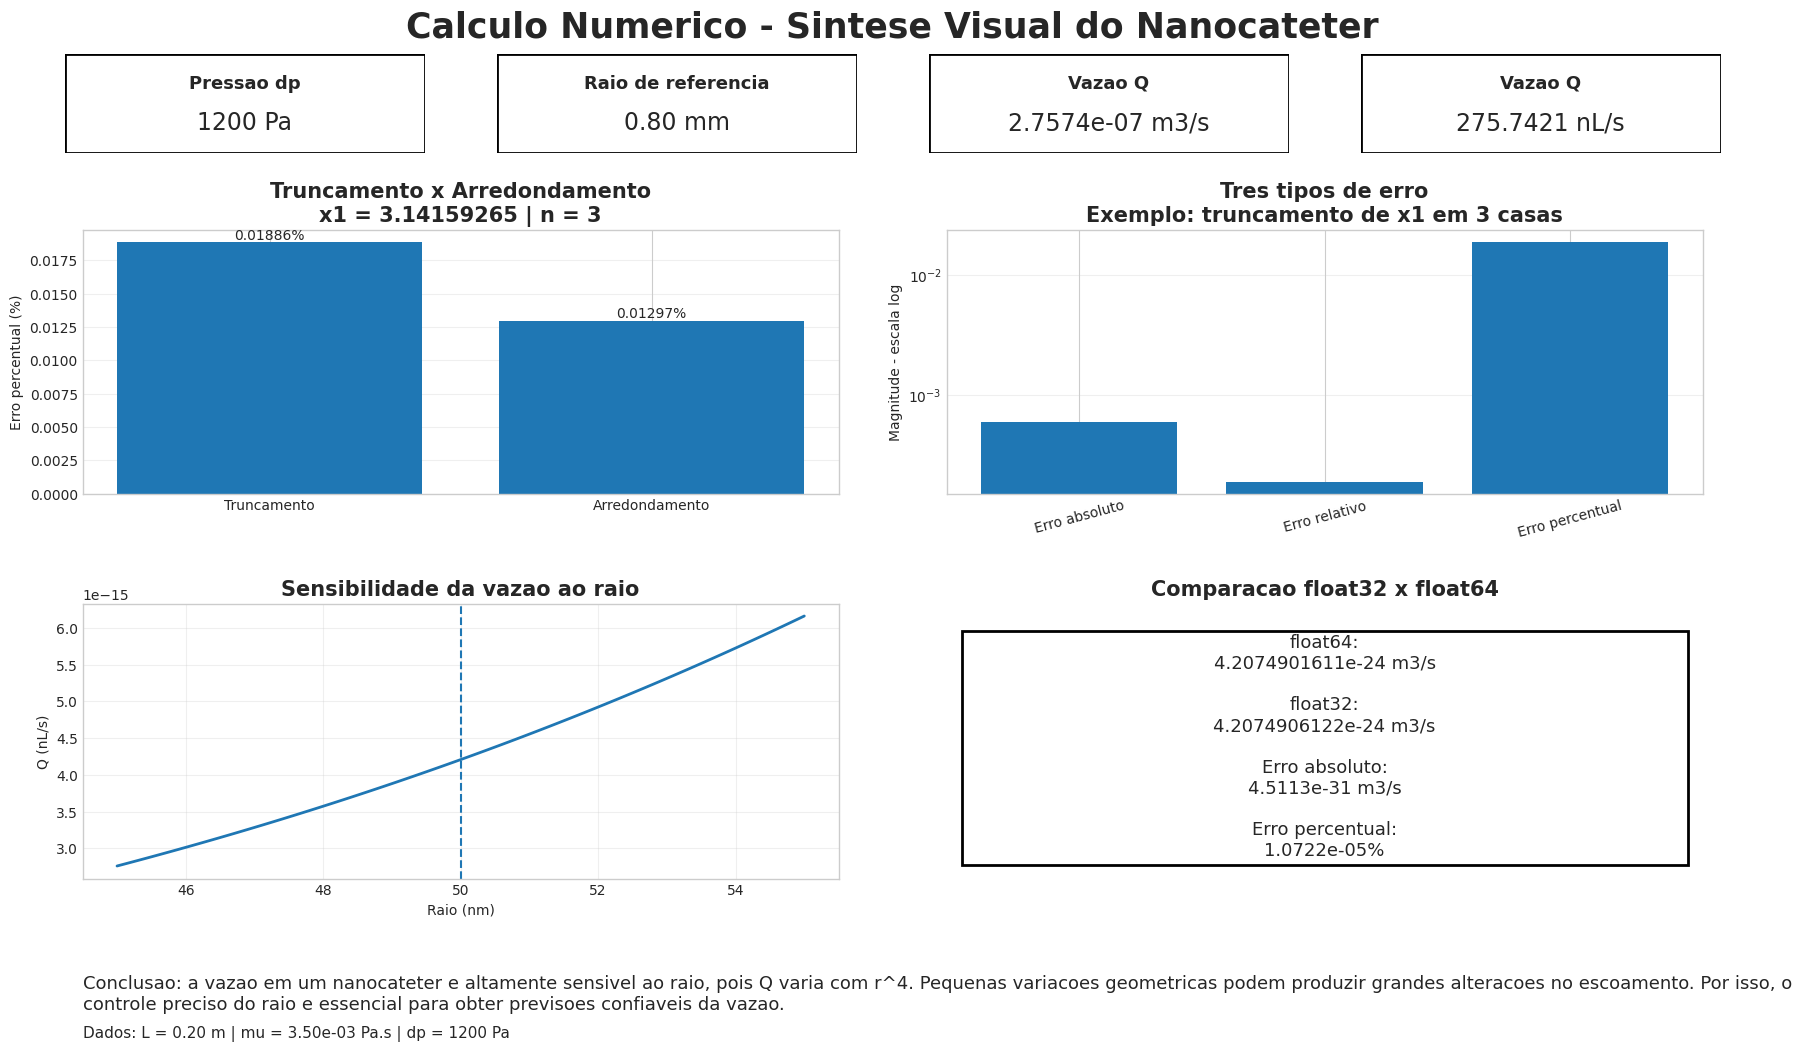

In [76]:
from IPython.display import Image, display

display(Image(filename="quadro_unico_resultados_nanocateter.png"))

**8) GIF demonstrativo**

Vazao de referencia:
Q(50 nm) = 4.207490e-24 m3/s
Q(50 nm) = 4.207490e-15 nL/s

GIF CRIADO COM SUCESSO!
Arquivo: /content/nanocateter_vazao.gif
Quantidade de quadros: 41
Raio inicial: 45 nm
Raio final: 55 nm


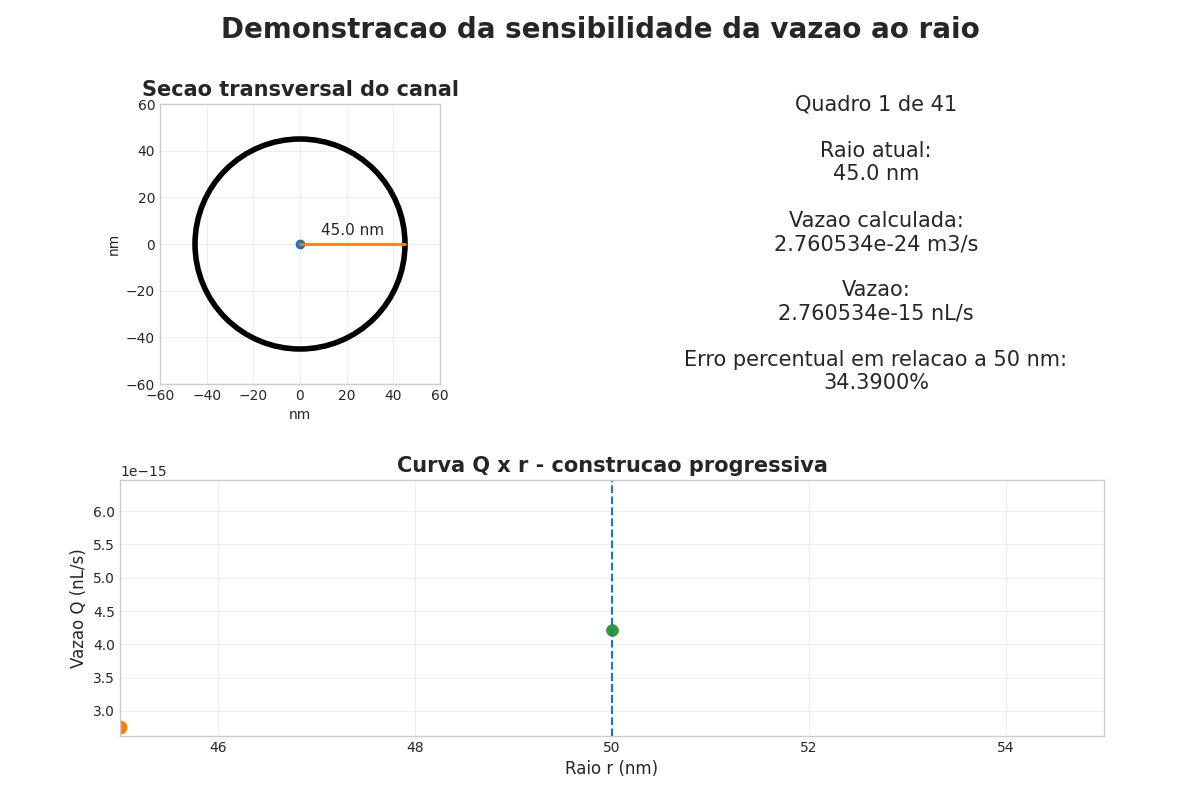

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from pathlib import Path

# CONFIGURACAO

plt.rcParams["font.family"] = "DejaVu Sans"


# DADOS DO NANOCATETER

L = 0.20              # comprimento (m)
mu = 3.5e-3           # viscosidade (Pa.s)
dp = 1200.0           # diferenca de pressao (Pa)

r_referencia_nm = 50.0
r_referencia_m = r_referencia_nm * 1e-9

# FUNCAO DE HAGEN-POISEUILLE

def vazao(r, mu, dp, L):
    return (
        np.pi * r**4 * dp
        /
        (8 * mu * L)
    )

# VAZAO DE REFERENCIA EM r = 50 nm

Q_referencia = vazao(
    r_referencia_m,
    mu,
    dp,
    L
)

print("Vazao de referencia:")
print(f"Q(50 nm) = {Q_referencia:.6e} m3/s")
print(f"Q(50 nm) = {Q_referencia * 1e9:.6e} nL/s")

# RAIOS DOS 41 QUADROS
# 45 nm -> 55 nm

raios_nm = np.linspace(
    45,
    55,
    41
)

raios_m = raios_nm * 1e-9

# CALCULAR TODAS AS VAZOES

vazoes = vazao(
    raios_m,
    mu,
    dp,
    L
)

# CALCULAR ERRO PERCENTUAL
# EM RELACAO A 50 nm

erros_percentuais = (
    np.abs(vazoes - Q_referencia)
    /
    np.abs(Q_referencia)
    * 100
)

# CRIAR FIGURA

fig = plt.figure(
    figsize=(12, 8),
    dpi=100
)

fig.patch.set_facecolor("white")


# FUNCAO DE ATUALIZACAO DO GIF

def atualizar(frame):

    # Limpar a figura
    fig.clear()

    # DADOS DO QUADRO ATUAL

    raio_nm = raios_nm[frame]
    raio_m = raios_m[frame]

    Q_atual = vazoes[frame]

    erro_atual = erros_percentuais[frame]

    # TITULO

    fig.suptitle(
        "Demonstracao da sensibilidade da vazao ao raio",
        fontsize=20,
        fontweight="bold"
    )

    # PAINEL 1
    # SECAO TRANSVERSAL

    ax1 = fig.add_axes([
        0.06,
        0.52,
        0.38,
        0.35
    ])

    ax1.set_xlim(
        -60,
        60
    )

    ax1.set_ylim(
        -60,
        60
    )

    ax1.set_aspect(
        "equal"
    )

    # Circulo representando a secao do nanocateter
    circulo = Circle(
        (0, 0),
        raio_nm,
        fill=False,
        linewidth=4
    )

    ax1.add_patch(
        circulo
    )

    # Centro
    ax1.plot(
        0,
        0,
        "o"
    )

    # Linha indicando o raio
    ax1.plot(
        [0, raio_nm],
        [0, 0],
        linewidth=2
    )

    # Texto do raio
    ax1.text(
        raio_nm / 2,
        4,
        f"{raio_nm:.1f} nm",
        ha="center",
        fontsize=11
    )

    ax1.set_title(
        "Secao transversal do canal",
        fontsize=15,
        fontweight="bold"
    )

    ax1.set_xlabel(
        "nm"
    )

    ax1.set_ylabel(
        "nm"
    )

    ax1.grid(
        True,
        alpha=0.3
    )

    # PAINEL 2
    # INFORMACOES

    ax2 = fig.add_axes([
        0.52,
        0.52,
        0.42,
        0.35
    ])

    ax2.axis("off")

    texto = (
        f"Quadro {frame + 1} de {len(raios_nm)}\n\n"

        f"Raio atual:\n"
        f"{raio_nm:.1f} nm\n\n"

        f"Vazao calculada:\n"
        f"{Q_atual:.6e} m3/s\n\n"

        f"Vazao:\n"
        f"{Q_atual * 1e9:.6e} nL/s\n\n"

        f"Erro percentual em relacao a 50 nm:\n"
        f"{erro_atual:.4f}%"
    )

    ax2.text(
        0.5,
        0.5,
        texto,
        ha="center",
        va="center",
        fontsize=15
    )

    # PAINEL 3
    # CURVA Q x r

    ax3 = fig.add_axes([
        0.10,
        0.08,
        0.82,
        0.32
    ])

    # Curva sendo construida progressivamente
    ax3.plot(
        raios_nm[:frame + 1],
        vazoes[:frame + 1] * 1e9,
        marker="o",
        markersize=4,
        linewidth=2
    )

    # Ponto atual
    ax3.plot(
        raio_nm,
        Q_atual * 1e9,
        "o",
        markersize=9
    )

    # Ponto de referencia em 50 nm
    ax3.plot(
        r_referencia_nm,
        Q_referencia * 1e9,
        "o",
        markersize=8
    )

    # Linha vertical no raio de referencia
    ax3.axvline(
        50,
        linestyle="--",
        linewidth=1.5
    )

    ax3.set_xlim(
        45,
        55
    )

    ax3.set_ylim(
        vazoes.min() * 1e9 * 0.95,
        vazoes.max() * 1e9 * 1.05
    )

    ax3.set_xlabel(
        "Raio r (nm)",
        fontsize=12
    )

    ax3.set_ylabel(
        "Vazao Q (nL/s)",
        fontsize=12
    )

    ax3.set_title(
        "Curva Q x r - construcao progressiva",
        fontsize=15,
        fontweight="bold"
    )

    ax3.grid(
        True,
        alpha=0.3
    )

# CRIAR ANIMACAO

animacao = FuncAnimation(
    fig,
    atualizar,
    frames=len(raios_nm),
    interval=150,
    repeat=True
)

# SALVAR GIF

arquivo_gif = "nanocateter_vazao.gif"

animacao.save(
    arquivo_gif,
    writer=PillowWriter(
        fps=7
    )
)

plt.close(fig)

# VERIFICAR ARQUIVO

arquivo = Path(
    arquivo_gif
)

if arquivo.exists():

    print()
    print("=" * 60)
    print("GIF CRIADO COM SUCESSO!")
    print("=" * 60)

    print(
        f"Arquivo: {arquivo.resolve()}"
    )

    print(
        f"Quantidade de quadros: {len(raios_nm)}"
    )

    print(
        "Raio inicial: 45 nm"
    )

    print(
        "Raio final: 55 nm"
    )

else:

    print(
        "ERRO: o GIF nao foi criado."
    )

from IPython.display import Image, display

display(Image(filename="nanocateter_vazao.gif"))